In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("smartcart_customers.csv")
df.head()
# df.info()
# df.isnull().sum()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Data Preprocessing

## 1. Handle missing values

In [3]:
#method 1 

df["Income"] = df["Income"].fillna(df["Income"].median())

In [4]:
# method 2 
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="median")
df["Income"] = num_imp.fit_transform(df[["Income"]])

In [5]:
df.isnull().sum()


ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering 

In [6]:
# 1.Age 
df["Age"] = 2026-df["Year_Birth"]


In [7]:
#2.Customer_Tenure_Days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True) #dayfirst=True because pandas ke andar MM-DD-YYYY wala fromat hota hai hamare data mai DD-MM-YYYY wala isliye

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [8]:
# Total Spending

df["Total_Spending"] = df["MntWines"] +  df["MntFruits"] +  df["MntMeatProducts"] +  df["MntFishProducts"] +  df["MntSweetProducts"] +  df["MntGoldProds"]


In [9]:
# Children

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [49]:
# Education
df["Education"].value_counts()

df["Education"] = df["Education"].map({
    "Basic": "Undergraduate" , "2n Cycle": "Undergraduate",
    "Graduation":  "Graduate" ,
    "PhD": "Postgraduate" , "Master": "Postgraduate",   
})

In [50]:
# Martical_Status 

df["Marital_Status"].value_counts()

df["Living_With"] =  df["Marital_Status"].map({
    "Married" : "Partner" ,  "Together" : "Partner" ,
    "Single" : "Alone" ,  "Divorced" : "Alone" ,  "Widow" : "Alone" ,  "YOLO" : "Alone" ,  "Absurd" : "Alone" ,
})

In [52]:
df.head()
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

# Drop Columns

In [13]:
cols = ["ID" , "Year_Birth" , "Kidhome", "Teenhome", "Marital_Status", "Dt_Customer" ]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts",  "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns = cols_to_drop)


In [14]:
df_cleaned.shape

(2240, 15)

# Outliers 


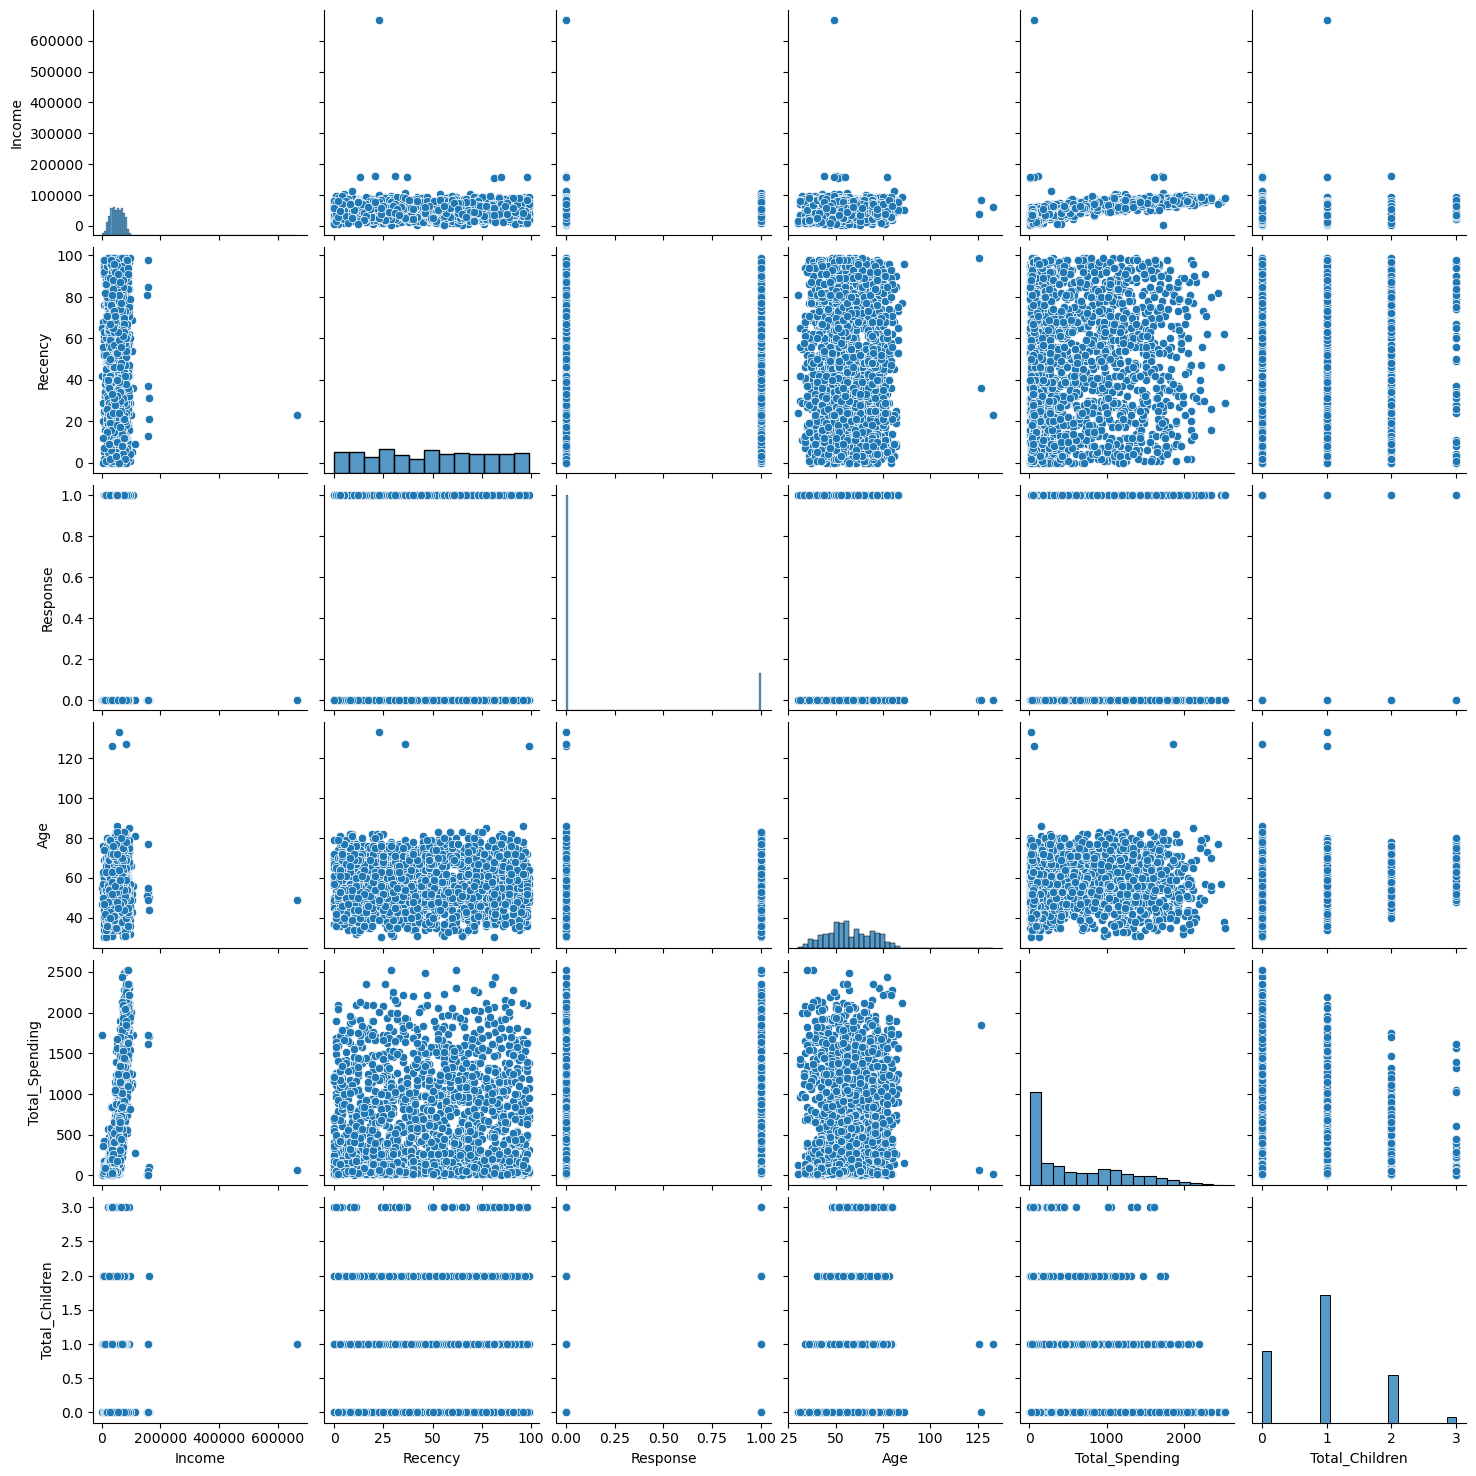

In [15]:
cols  = ["Income", "Recency","Response","Age","Total_Spending","Total_Children"]

# relative plots of some features - pair plots 
sns.pairplot(df_cleaned[cols])

In [16]:
# remove outliers

print("data size with outliers : ", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600000)]

print("data size without outliers : ", len(df_cleaned))

data size with outliers :  2240
data size without outliers :  2236


# Heatmap 

In [17]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

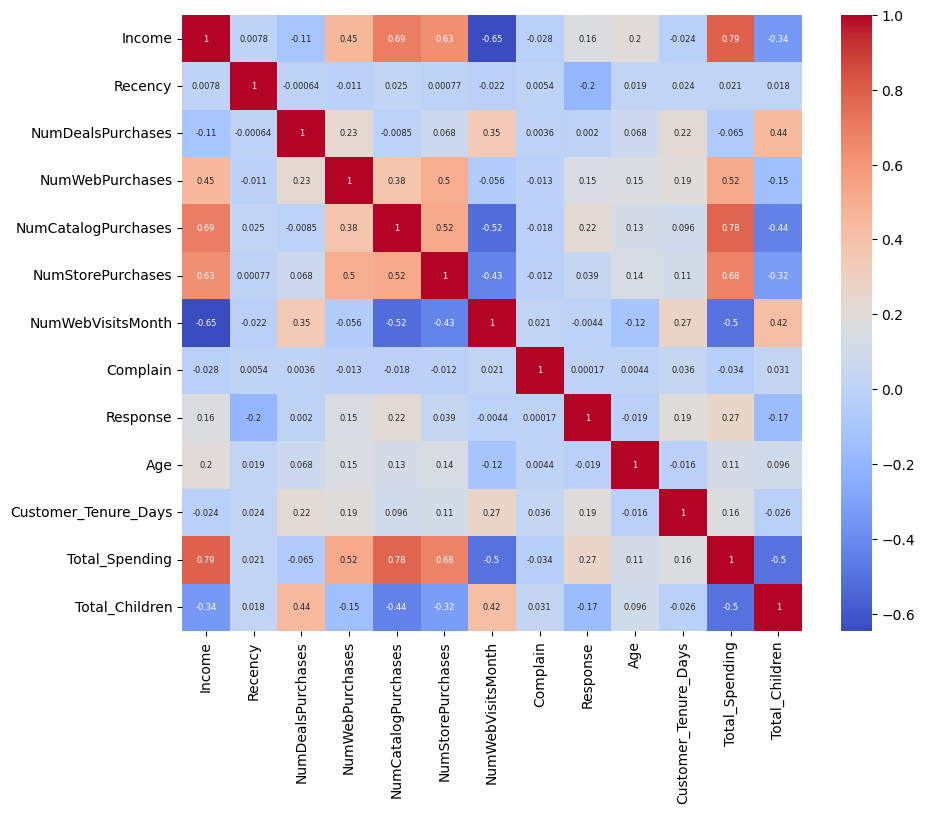

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    annot_kws = {"size" : 6 },
    cmap = "coolwarm"
    
)

# ENCONDING


In [19]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])


In [20]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [21]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols), enc_df], axis=1)

In [22]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [23]:
X = df_encoded

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualize

In [25]:
# 2D
from sklearn.decomposition import PCA

pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.23163158 0.11385454 0.10405815]


Text(0.5, 0.92, '3d Projection')

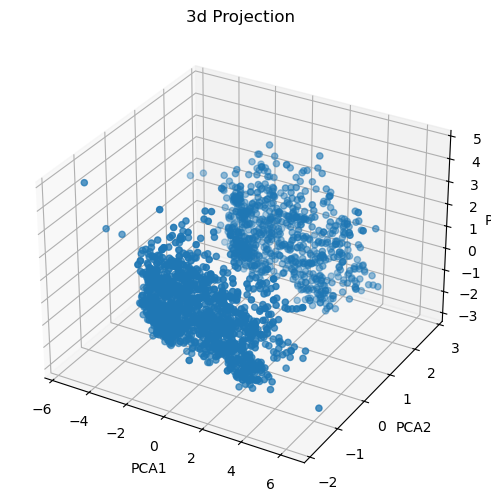

In [26]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter( X_pca[:,0],  X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d Projection")

# Analyze K value 

1. Elbow Method

In [27]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmean = KMeans(n_clusters = k, random_state = 42)
    kmean.fit_predict(X_pca)
    wcss.append(kmean.inertia_)

<Axes: >

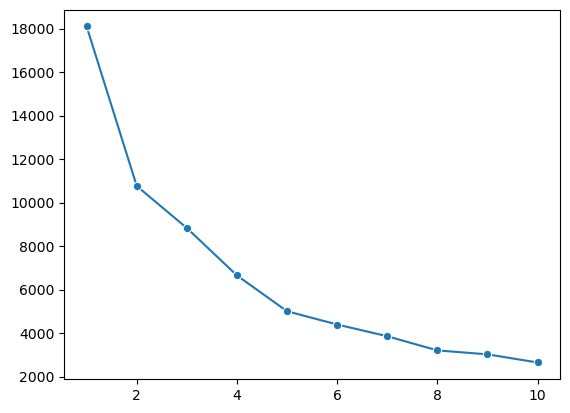

In [28]:
sns.lineplot(x=range(1,11) , y=wcss, marker= "o")

In [29]:
!pip install kneed

In [30]:
from kneed import KneeLocator

In [31]:
kneed = KneeLocator(range(1, 11), wcss, direction="decreasing", curve="convex")

print("optimal k value :" , kneed.elbow)

optimal k value : 4


## Silhouette Score

In [32]:
from sklearn.metrics import silhouette_score


In [33]:


scores =[]

for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)
    

In [34]:
print("k value :", silhouette_score(X_pca, labels))

k value : 0.4029117336489473


<Axes: >

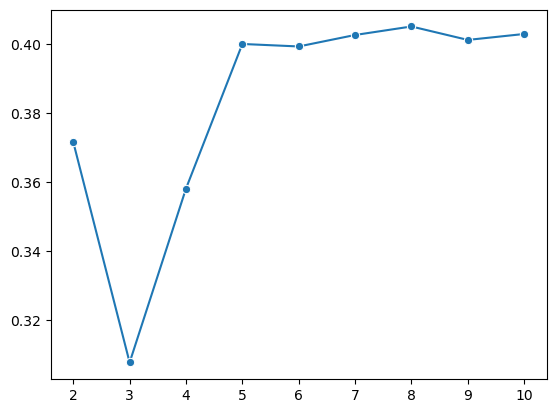

In [35]:
sns.lineplot(x=range(2,11) , y=scores, marker= "o")

Text(0, 0.5, 'ss')

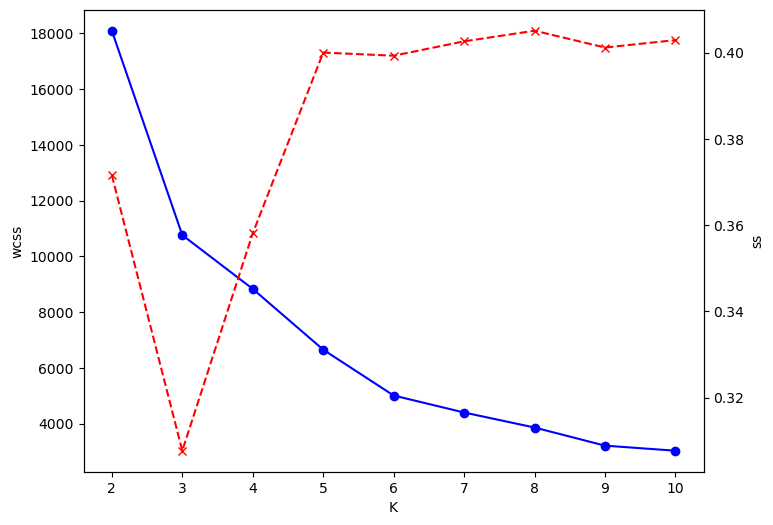

In [36]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker= "o" , color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker= "x" , color="red" , linestyle="--")
ax2.set_ylabel("ss")

# Clustering

In [37]:
# kmeans 

k = 4

kmeans = KMeans(n_clusters = k , random_state = 42)
labels_Kmeans = kmeans.fit_predict(X_pca)

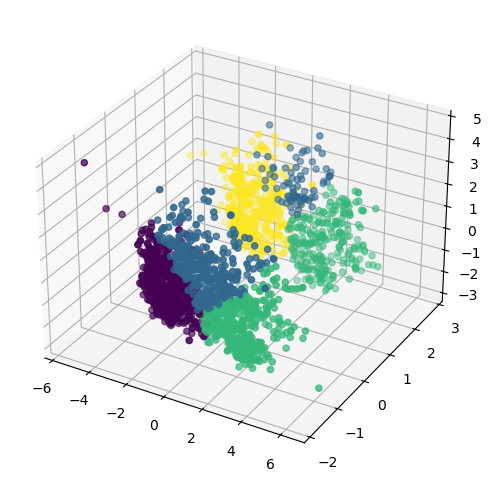

In [38]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter( X_pca[:,0],  X_pca[:,1], X_pca[:,2], c=labels_Kmeans)



In [39]:
# Agglomerative cluster

from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg.fit_predict(X_pca)


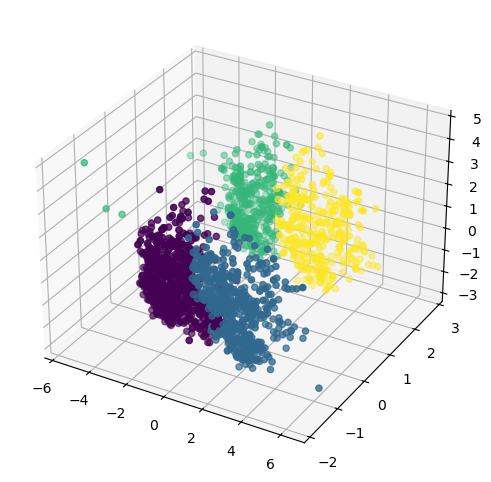

In [40]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter( X_pca[:,0],  X_pca[:,1], X_pca[:,2], c=labels_agg)



# Characterization of cluster

In [41]:

X["cluster"] = labels_agg

In [42]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

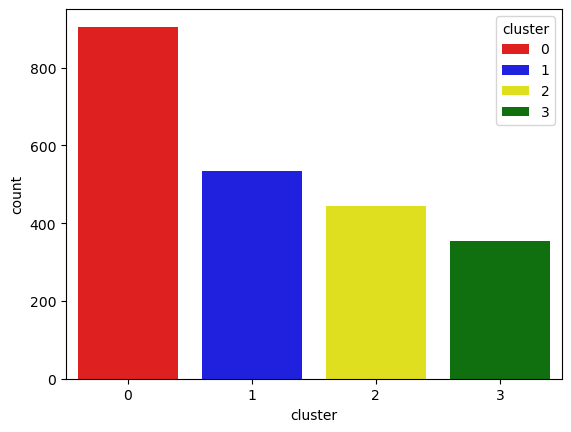

In [43]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

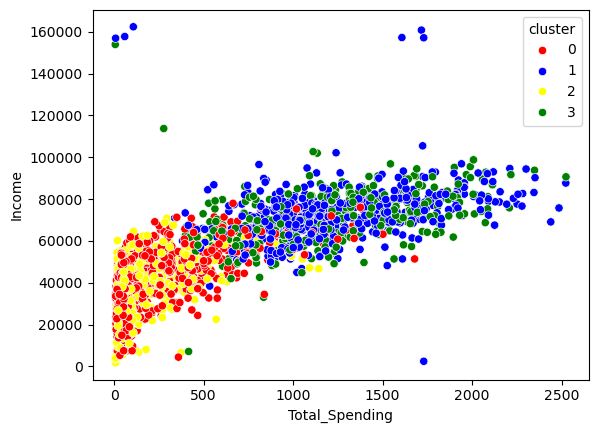

In [46]:
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

# Cluster Summary

In [48]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         